# Robot Navigation Action Classification

Programming in Python Final-Term Group Project

## 1. Dataset and Problem Context

The goal of this project is to classify the navigation action of a mobile robot using ultrasonic sensor readings.

Each observation contains readings from 24 ultrasonic sensors positioned around the robot. The target variable represents one of four navigation actions:

- Move-Forward
- Slight-Right-Turn
- Sharp-Right-Turn
- Slight-Left-Turn

The dataset contains 5,456 observations.

Source: UCI Machine Learning Repository, Wall-Following Robot Navigation Data.

DOI: 10.24432/C57C8W

## 2. Import Libraries


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 3. Load the Dataset

In [2]:
sensor_columns = [
    "US1", "US2", "US3", "US4", "US5", "US6",
    "US7", "US8", "US9", "US10", "US11", "US12",
    "US13", "US14", "US15", "US16", "US17", "US18",
    "US19", "US20", "US21", "US22", "US23", "US24"
]

column_names = sensor_columns + ["Class"]

print(column_names)

['US1', 'US2', 'US3', 'US4', 'US5', 'US6', 'US7', 'US8', 'US9', 'US10', 'US11', 'US12', 'US13', 'US14', 'US15', 'US16', 'US17', 'US18', 'US19', 'US20', 'US21', 'US22', 'US23', 'US24', 'Class']


In [5]:
df_raw = pd.read_csv(
    "../data/raw/sensor_readings_24.data",
    sep=",",
    header=None,
    names=column_names
)

In [6]:
# Keep the raw DataFrame unchanged and work on a copy
df = df_raw.copy()

## 4. Initial Dataset Inspection

In [7]:
df.head(10)

,US1,US2,US3,US4,US5,US6,US7,US8,US9,US10,...,US16,US17,US18,US19,US20,US21,US22,US23,US24,Class
0,0.438,0.498,3.625,3.645,5.0,2.918,5.000,2.351,2.332,2.643,...,0.593,0.502,0.493,0.504,0.445,0.431,0.444,0.440,0.429,Slight-Right-Turn
1,0.438,0.498,3.625,3.648,5.0,2.918,5.000,2.637,2.332,2.649,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.443,0.429,Slight-Right-Turn
2,0.438,0.498,3.625,3.629,5.0,2.918,5.000,2.637,2.334,2.643,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.446,0.429,Slight-Right-Turn
3,0.437,0.501,3.625,3.626,5.0,2.918,5.000,2.353,2.334,2.642,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.444,0.429,Slight-Right-Turn
4,0.438,0.498,3.626,3.629,5.0,2.918,5.000,2.640,2.334,2.639,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.441,0.429,Slight-Right-Turn
5,0.439,0.498,3.626,3.629,5.0,2.918,5.000,2.633,2.334,2.645,...,0.589,0.502,0.493,0.504,0.446,0.431,0.444,0.444,0.430,Slight-Right-Turn
6,0.440,5.000,3.627,3.628,5.0,2.919,3.028,2.346,2.330,2.638,...,0.588,0.501,0.492,0.504,0.451,0.433,0.446,0.444,0.432,Slight-Right-Turn
7,0.444,5.021,3.631,3.634,5.0,2.919,5.000,2.626,2.327,2.638,...,0.595,0.500,0.491,0.503,0.453,0.436,0.448,0.444,0.436,Slight-Right-Turn
8,0.451,5.025,3.635,3.639,5.0,2.920,3.027,2.620,2.323,2.632,...,0.595,0.499,0.491,0.502,0.457,0.440,0.453,0.454,0.442,Sharp-Right-Turn
9,0.458,5.022,3.640,3.644,5.0,2.922,5.000,2.346,2.321,2.628,...,0.590,0.496,0.490,0.498,0.462,0.444,0.458,0.461,0.449,Sharp-Right-Turn


In [8]:
df.tail(7)

,US1,US2,US3,US4,US5,US6,US7,US8,US9,US10,...,US16,US17,US18,US19,US20,US21,US22,US23,US24,Class
5449,1.646,3.925,3.958,2.771,2.756,2.337,2.439,1.127,1.785,1.077,...,0.674,0.662,0.672,0.753,5.000,1.026,5.0,5.0,1.594,Move-Forward
5450,0.911,3.939,3.976,2.775,2.763,2.573,2.436,1.106,1.781,1.059,...,0.667,0.655,0.665,1.591,5.000,1.035,5.0,5.0,5.000,Move-Forward
5451,0.910,5.000,3.997,2.785,2.770,2.572,2.433,1.087,1.772,1.040,...,0.660,0.648,0.657,0.686,5.000,1.045,5.0,5.0,1.562,Move-Forward
5452,0.926,5.000,4.015,2.792,2.777,2.571,1.768,1.071,1.762,1.021,...,0.652,0.640,0.649,1.593,1.616,1.058,5.0,5.0,1.085,Sharp-Right-Turn
5453,0.937,5.000,4.034,2.799,2.784,2.571,1.754,1.053,1.752,1.002,...,0.648,0.633,0.642,0.741,5.000,1.065,5.0,5.0,1.105,Sharp-Right-Turn
5454,0.945,4.052,4.052,2.809,2.791,2.441,1.757,1.034,1.743,0.983,...,0.641,0.626,0.635,0.754,5.000,1.076,5.0,5.0,1.118,Move-Forward
5455,0.950,4.066,5.000,2.819,2.798,2.570,2.422,1.016,1.739,0.964,...,0.635,0.618,0.628,0.776,5.000,1.083,5.0,5.0,1.168,Sharp-Right-Turn


In [9]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(list(df.columns))

Dataset shape: (5456, 25)

Column names:
['US1', 'US2', 'US3', 'US4', 'US5', 'US6', 'US7', 'US8', 'US9', 'US10', 'US11', 'US12', 'US13', 'US14', 'US15', 'US16', 'US17', 'US18', 'US19', 'US20', 'US21', 'US22', 'US23', 'US24', 'Class']


In [10]:
print(df.dtypes)

US1      float64
US2      float64
US3      float64
US4      float64
US5      float64
US6      float64
US7      float64
US8      float64
US9      float64
US10     float64
US11     float64
US12     float64
US13     float64
US14     float64
US15     float64
US16     float64
US17     float64
US18     float64
US19     float64
US20     float64
US21     float64
US22     float64
US23     float64
US24     float64
Class        str
dtype: object


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5456 entries, 0 to 5455
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   US1     5456 non-null   float64
 1   US2     5456 non-null   float64
 2   US3     5456 non-null   float64
 3   US4     5456 non-null   float64
 4   US5     5456 non-null   float64
 5   US6     5456 non-null   float64
 6   US7     5456 non-null   float64
 7   US8     5456 non-null   float64
 8   US9     5456 non-null   float64
 9   US10    5456 non-null   float64
 10  US11    5456 non-null   float64
 11  US12    5456 non-null   float64
 12  US13    5456 non-null   float64
 13  US14    5456 non-null   float64
 14  US15    5456 non-null   float64
 15  US16    5456 non-null   float64
 16  US17    5456 non-null   float64
 17  US18    5456 non-null   float64
 18  US19    5456 non-null   float64
 19  US20    5456 non-null   float64
 20  US21    5456 non-null   float64
 21  US22    5456 non-null   float64
 22  US23    545

## 5. Descriptive Statistics

In [12]:
df.describe()

,US1,US2,US3,US4,US5,US6,US7,US8,US9,US10,...,US15,US16,US17,US18,US19,US20,US21,US22,US23,US24
count,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,...,5456.000000,5456.000000,5456.000000,5456.000000,5456.00000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000
mean,1.471617,2.327043,2.489347,2.796501,2.958552,2.893073,3.351113,2.540397,3.125621,2.832386,...,2.205772,1.202111,0.989831,0.910273,1.05811,1.076320,1.015923,1.778034,1.555045,1.578508
std,0.802801,1.410146,1.247435,1.309368,1.339225,1.282575,1.413692,1.111554,1.356965,1.307843,...,1.715435,1.098568,0.942075,0.889527,1.14463,1.141498,0.887439,1.571686,1.291447,1.150480
min,0.400000,0.437000,0.470000,0.833000,1.120000,1.114000,1.122000,0.859000,0.836000,0.810000,...,0.495000,0.424000,0.373000,0.354000,0.34000,0.355000,0.380000,0.370000,0.367000,0.377000
25%,0.921000,1.362000,1.538750,1.731000,1.774000,1.785750,1.930750,1.618000,1.799750,1.636000,...,0.860000,0.690000,0.581000,0.529750,0.52300,0.541750,0.567000,0.743000,0.792000,0.884000
50%,1.335000,1.904500,2.064000,2.458000,2.667000,2.682500,3.225500,2.172000,2.802000,2.679000,...,1.328500,0.803000,0.738000,0.685000,0.69100,0.693000,0.764000,1.030500,1.071000,1.289000
75%,1.814000,2.681500,2.739250,4.093500,4.314500,3.835250,5.000000,3.193000,5.000000,3.526250,...,4.436250,1.159000,0.913000,0.837000,0.85700,0.863000,1.002250,2.068250,1.559500,1.657250
max,5.000000,5.025000,5.029000,5.017000,5.000000,5.005000,5.008000,5.087000,5.000000,5.022000,...,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000


In [13]:
df.describe(include="all")

,US1,US2,US3,US4,US5,US6,US7,US8,US9,US10,...,US16,US17,US18,US19,US20,US21,US22,US23,US24,Class
count,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,...,5456.000000,5456.000000,5456.000000,5456.00000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Move-Forward
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2205
mean,1.471617,2.327043,2.489347,2.796501,2.958552,2.893073,3.351113,2.540397,3.125621,2.832386,...,1.202111,0.989831,0.910273,1.05811,1.076320,1.015923,1.778034,1.555045,1.578508,NaN
std,0.802801,1.410146,1.247435,1.309368,1.339225,1.282575,1.413692,1.111554,1.356965,1.307843,...,1.098568,0.942075,0.889527,1.14463,1.141498,0.887439,1.571686,1.291447,1.150480,NaN
min,0.400000,0.437000,0.470000,0.833000,1.120000,1.114000,1.122000,0.859000,0.836000,0.810000,...,0.424000,0.373000,0.354000,0.34000,0.355000,0.380000,0.370000,0.367000,0.377000,NaN
25%,0.921000,1.362000,1.538750,1.731000,1.774000,1.785750,1.930750,1.618000,1.799750,1.636000,...,0.690000,0.581000,0.529750,0.52300,0.541750,0.567000,0.743000,0.792000,0.884000,NaN
50%,1.335000,1.904500,2.064000,2.458000,2.667000,2.682500,3.225500,2.172000,2.802000,2.679000,...,0.803000,0.738000,0.685000,0.69100,0.693000,0.764000,1.030500,1.071000,1.289000,NaN
75%,1.814000,2.681500,2.739250,4.093500,4.314500,3.835250,5.000000,3.193000,5.000000,3.526250,...,1.159000,0.913000,0.837000,0.85700,0.863000,1.002250,2.068250,1.559500,1.657250,NaN


## 6. Data Audit

In [14]:
missing_values = df.isna().sum()

print(missing_values)

US1      0
US2      0
US3      0
US4      0
US5      0
US6      0
US7      0
US8      0
US9      0
US10     0
US11     0
US12     0
US13     0
US14     0
US15     0
US16     0
US17     0
US18     0
US19     0
US20     0
US21     0
US22     0
US23     0
US24     0
Class    0
dtype: int64


In [15]:
print("Total missing values:", df.isna().sum().sum())

Total missing values: 0


In [16]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [17]:
print("Unique class labels:")
print(df["Class"].unique())

Unique class labels:
<StringArray>
['Slight-Right-Turn', 'Sharp-Right-Turn', 'Move-Forward', 'Slight-Left-Turn']
Length: 4, dtype: str


In [18]:
expected_classes = [
    "Move-Forward",
    "Slight-Right-Turn",
    "Sharp-Right-Turn",
    "Slight-Left-Turn"
]

assert df["Class"].isin(expected_classes).all()

print("All class labels are valid.")

All class labels are valid.


In [19]:
all_non_negative = (df[sensor_columns] >= 0).all().all()

print("All sensor readings are non-negative:", all_non_negative)

All sensor readings are non-negative: True


In [20]:
print("Minimum value for each sensor:")
print(df[sensor_columns].min())

print("\nMaximum value for each sensor:")
print(df[sensor_columns].max())

Minimum value for each sensor:
US1     0.400
US2     0.437
US3     0.470
US4     0.833
US5     1.120
US6     1.114
US7     1.122
US8     0.859
US9     0.836
US10    0.810
US11    0.783
US12    0.778
US13    0.770
US14    0.756
US15    0.495
US16    0.424
US17    0.373
US18    0.354
US19    0.340
US20    0.355
US21    0.380
US22    0.370
US23    0.367
US24    0.377
dtype: float64

Maximum value for each sensor:
US1     5.000
US2     5.025
US3     5.029
US4     5.017
US5     5.000
US6     5.005
US7     5.008
US8     5.087
US9     5.000
US10    5.022
US11    5.019
US12    5.000
US13    5.003
US14    5.000
US15    5.000
US16    5.000
US17    5.000
US18    5.000
US19    5.000
US20    5.000
US21    5.000
US22    5.000
US23    5.000
US24    5.000
dtype: float64


### Cleaning Decision

The raw dataset is kept unchanged.

The audit checks missing values, duplicate observations, class labels, data types, and sensor-value ranges.

No missing-value imputation is applied when no missing values are found. Sensor readings are not removed simply because they are relatively high or low, because no justified invalid maximum threshold is provided for the project. Duplicate observations are reported but are retained because repeated sensor states may occur in sequential measurements.

The working DataFrame therefore preserves the original observations unless a clearly invalid value is identified.

## 7. Target Class Distribution

In [21]:
class_counts = df["Class"].value_counts()

print("Class counts:")
print(class_counts)

Class counts:
Class
Move-Forward         2205
Sharp-Right-Turn     2097
Slight-Right-Turn     826
Slight-Left-Turn      328
Name: count, dtype: int64


In [22]:
class_percentages = df["Class"].value_counts(normalize=True) * 100

print("Class percentages:")
print(class_percentages)

Class percentages:
Class
Move-Forward         40.414223
Sharp-Right-Turn     38.434751
Slight-Right-Turn    15.139296
Slight-Left-Turn      6.011730
Name: proportion, dtype: float64


## 8. Exploratory Data Analysis

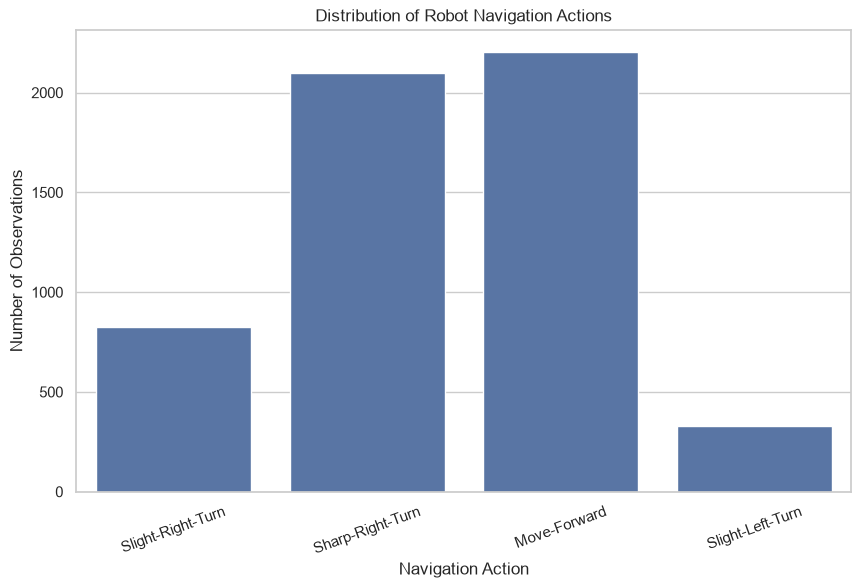

In [23]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Class"
)

plt.title("Distribution of Robot Navigation Actions")
plt.xlabel("Navigation Action")
plt.ylabel("Number of Observations")
plt.xticks(rotation=20)

plt.show()

### Class Distribution Observation

The target classes are not equally represented. `Move-Forward` and `Sharp-Right-Turn` contain many more observations than `Slight-Left-Turn`. This class imbalance should be considered later when the machine-learning models are evaluated, so accuracy alone should not be used to judge performance.

### Representative Sensor Distributions

Four sensors from different positions around the robot are inspected to understand the distribution of ultrasonic distance readings.

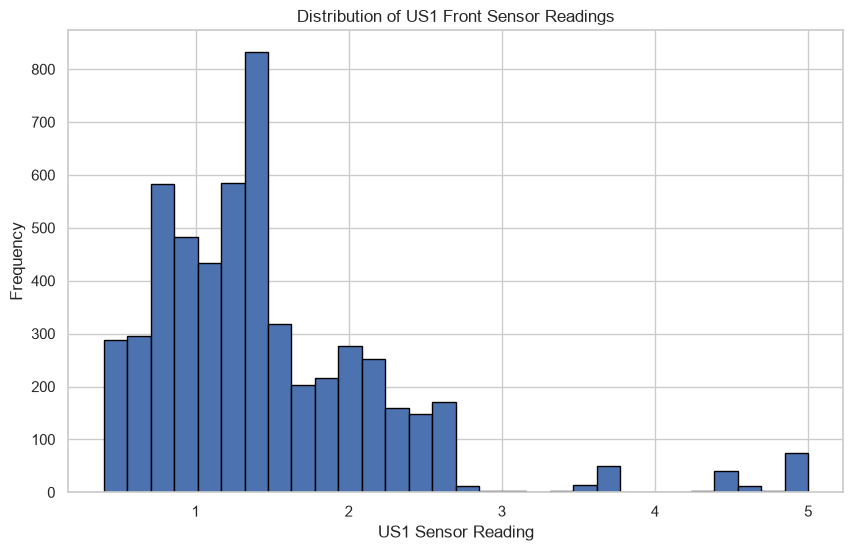

In [24]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["US1"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("US1 Sensor Reading")
plt.ylabel("Frequency")
plt.title("Distribution of US1 Front Sensor Readings")

plt.show()

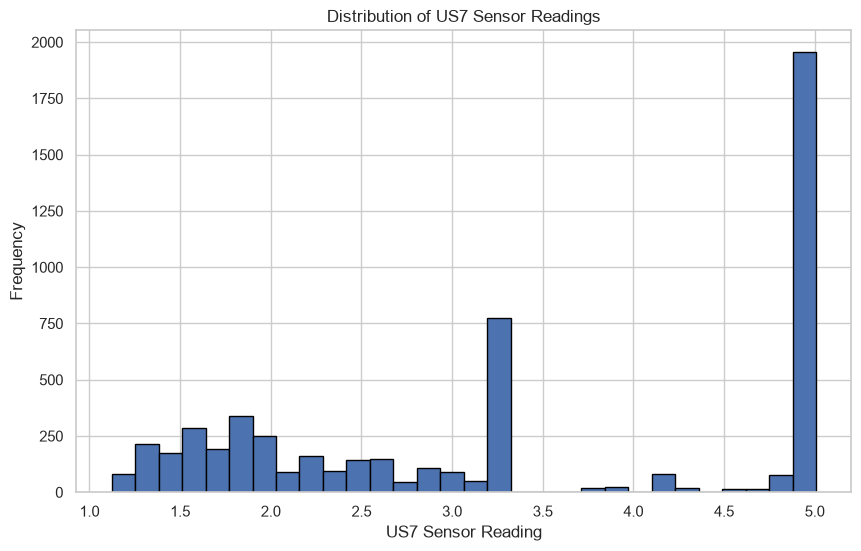

In [25]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["US7"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("US7 Sensor Reading")
plt.ylabel("Frequency")
plt.title("Distribution of US7 Sensor Readings")

plt.show()

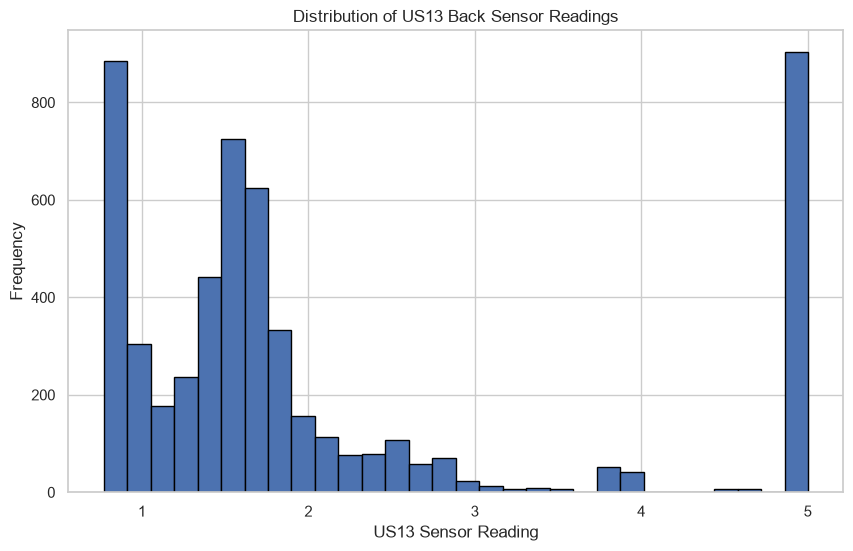

In [26]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["US13"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("US13 Sensor Reading")
plt.ylabel("Frequency")
plt.title("Distribution of US13 Back Sensor Readings")

plt.show()

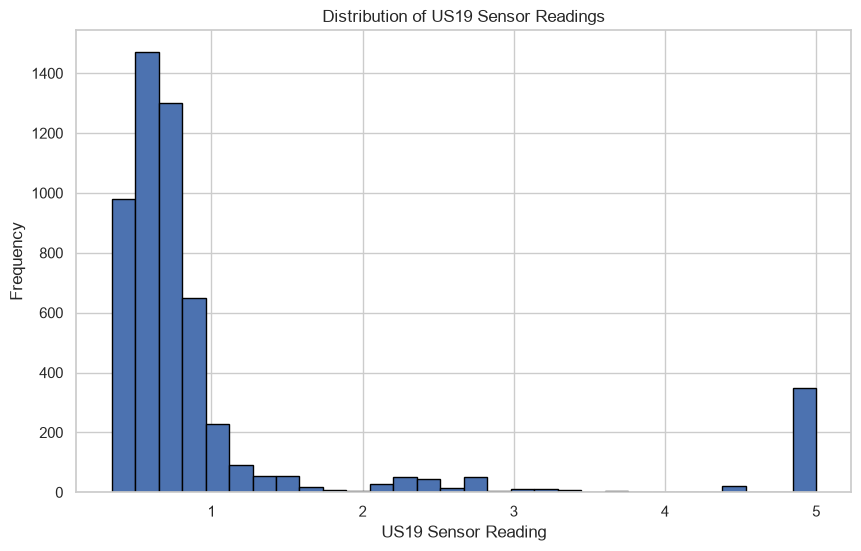

In [27]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["US19"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("US19 Sensor Reading")
plt.ylabel("Frequency")
plt.title("Distribution of US19 Sensor Readings")

plt.show()

### Sensor Distribution Observation

The sensor distributions are not identical across positions around the robot. Different sensors record different ranges and concentrations of distance values, which is expected because they measure obstacles from different directions.